In [13]:
import xarray as xr
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier


from sklearn.metrics import classification_report, r2_score
import torch
from torch.utils.data import TensorDataset, DataLoader
from skimage.metrics import structural_similarity as ssim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm
from sklearn.metrics import classification_report, jaccard_score, cohen_kappa_score, confusion_matrix, f1_score
import seaborn as sns
from astral import moon

from io import BytesIO
from openpyxl.drawing.image import Image
import random


Loading and aligning dataset...
Preprocessing and scaling...
Creating rolling windows...
Train: X torch.Size([120, 12, 14, 62, 29]) | y torch.Size([120, 1, 30, 17])
Val:   X torch.Size([24, 12, 14, 62, 29]) | y torch.Size([24, 1, 30, 17])
Test:  X torch.Size([12, 12, 14, 62, 29]) | y torch.Size([12, 1, 30, 17])
Calculating Variance Inflation Factor (VIF)...

--- VIF Results ---


,feature,VIF
8,PP,21.333150
7,CHL,10.537154
0,TO,8.682902
2,TOB,8.395398
6,ZO,5.525965
1,SO,5.257247
11,ZSD,5.032414
13,MCOS,4.602529
12,MSEN,3.740095
9,CDM,2.776847



Suggested variables to drop (Correlation > 0.75): ['ZO', 'PP', 'CDM']


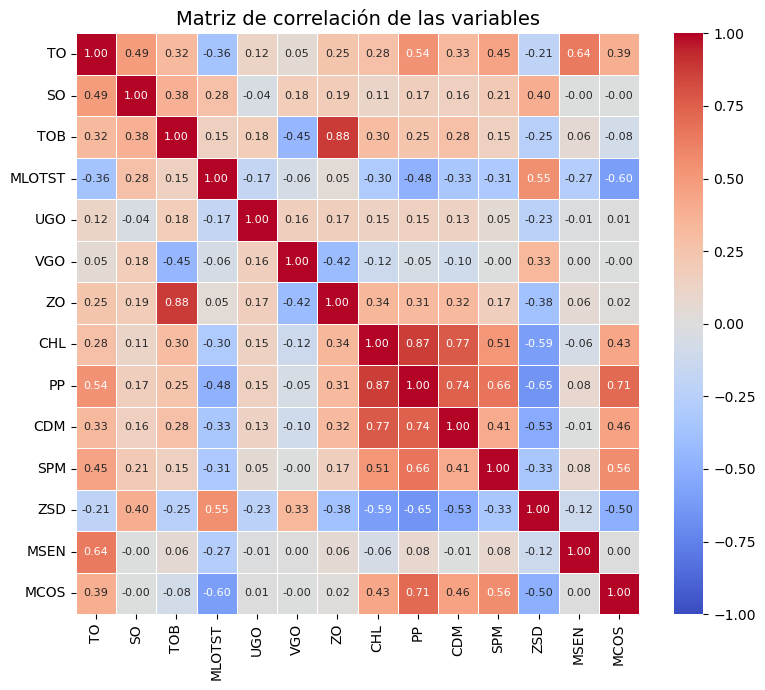

In [14]:
from dataset_loader import DataBuilder

sp = "SQA"
features = ["TO", "SO", "TOB", 
            "MLOTST", "UGO", "VGO", "ZO", 
            "CHL", "PP", "CDM", "SPM", "ZSD",
            "MSEN", "MCOS", #"Año",
            ]
todas = False

data_builder = DataBuilder(target_var="CPUE_class", sp=sp, features=features, prediction_horizon=1, window_size=12, 
                           start_date="2012-01-01", end_date="2025-12-31",)

vars_names = data_builder.features
(X_train, y_train, m_train), (X_val, y_val, m_val), (X_test, y_test, m_test) = data_builder.get_splits()

def prep_ml_data(X, y, m=None):
    """
    Converts 5D input tensors and 3D target tensors into 2D arrays for ML
    """
    # Move to CPU and convert to numpy if dealing with PyTorch Tensors
    if isinstance(X, torch.Tensor):
        X = X.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()
    if isinstance(m, torch.Tensor):
        m = m.detach().cpu().numpy()

    N = X.shape[0]
    
    # Flatten features: (N, T, C, H_x, W_x) -> (N, T * C * H_x * W_x)
    # For your train data: (72, 12, 11, 94, 48) -> (72, 595584)
    X_rf = X.reshape(N, -1)
    
    # Flatten targets: (N, H_y, W_y) -> (N, H_y * W_y)
    # For your train data: (72, 37, 20) -> (72, 740)
    y_rf = y.reshape(N, -1)
    
    if m is not None:
        m_rf = m.reshape(N, -1)
        return X_rf, y_rf, m_rf
    else:
        return X_rf, y_rf

X_train_ml, y_train_ml, m_train_ml = prep_ml_data(X_train, y_train, m_train)
X_val_ml, y_val_ml, m_val_ml = prep_ml_data(X_val, y_val, m_val)
X_test_ml, y_test_ml, m_test_ml = prep_ml_data(X_test, y_test, m_test)



prediction_horizon = y_test.shape[1]
H_val, W_val = y_val.shape[-2], y_val.shape[-1]
H_out, W_out = y_test.shape[-2], y_test.shape[-1]

m_true_val = m_val_ml.reshape(-1, prediction_horizon, H_val, W_val)
y_true_val = y_val_ml.reshape( -1, prediction_horizon, H_val, W_val)

m_true = m_test_ml.reshape(-1, prediction_horizon, H_out, W_out)
y_true = y_test_ml.reshape(-1, prediction_horizon, H_out, W_out)

mask_flat = m_test_ml.astype(bool)


data_builder.plot_correlations()

In [15]:
def compute_metrics(y_test_ml, y_pred_flat, y_true, mask_spatial):

    # =====================================================
    # 1. FLATTEN FOR OVERALL METRICS
    # =====================================================
    y_test_flat = y_test_ml.flatten()
    y_pred_flat_1d = y_pred_flat.flatten()

    mask_spatial = mask_spatial.astype(bool)
    mask_flat = mask_spatial.flatten().astype(bool)

    y_test_masked = y_test_flat[mask_flat]
    y_pred_masked = y_pred_flat_1d[mask_flat]

    # =====================================================
    # 2. OVERALL CLASSIFICATION METRICS
    # =====================================================
    report = pd.DataFrame(classification_report(y_test_masked, y_pred_masked, labels=[0, 1, 2], output_dict=True, zero_division=0)).T
    iou_per_class = jaccard_score(y_test_masked, y_pred_masked, average=None, labels=[0, 1, 2], zero_division=0)
    kappa = cohen_kappa_score(y_test_masked, y_pred_masked)

    class_labels = ['Nada (0)', 'CPUE bajo (1)', 'CPUE alto (2)']
    cm = pd.DataFrame(confusion_matrix(y_test_masked, y_pred_masked, labels=[0, 1, 2]), index=class_labels, columns=class_labels)

    # =====================================================
    # 3. RESTORE (N, HORIZON, H, W)
    # =====================================================
    N, horizon, H_out, W_out = y_true.shape
    y_pred_4d = y_pred_flat.reshape(N, horizon, H_out, W_out)

    # =====================================================
    # 4. F1 CLASS 2 BY PREDICTION HORIZON
    # =====================================================


    f1_monthly = []

    for h in range(horizon):
        y_true_h = y_true[:, h, :, :]
        y_pred_h = y_pred_4d[:, h, :, :]
        mask_h = mask_spatial[:, h, :, :]

        y_true_h = y_true_h[mask_h]
        y_pred_h = y_pred_h[mask_h]

        f1_class2 = f1_score(y_true_h, y_pred_h, labels=[2], average=None, zero_division=0)[0]
        f1_monthly.append(f1_class2)

        print(f"Month +{h+1}: F1 class 2 = {f1_class2:.4f}")
    print("-" * 45)
    return report, iou_per_class, kappa, cm


In [16]:
iters = 2

# -------- Initialize Storage DataFrames/Lists for Iterations --------
importance_all_df = pd.DataFrame(columns=vars_names)
reports_list = []
iou_list = []
kappa_list = []
r2_plot_list = []

for i in range(iters):

    model = RandomForestClassifier(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=random.randint(0, 1000))
    model.fit(X_train_ml, y_train_ml)
    y_pred_flat = model.predict(X_test_ml)
    print(f"Model iteration {i+1}/{iters} trained.")
    # Compute metrics
    report, iou_per_class, kappa, cm = compute_metrics(y_test_ml, y_pred_flat, y_true, m_true)
    
    # Store scalar values
    kappa_list.append(kappa)
    
    # Store dataframes/arrays for structural averaging
    reports_list.append(report)
    iou_list.append(np.array(iou_per_class).flatten())

    # -------- Feature Importance Extraction --------
    raw_importances = model.feature_importances_
    T = X_train.shape[1]   # window (12)
    C = X_train.shape[2]   # number of variables/channels
    H_x = X_train.shape[3] # height (lat)
    W_x = X_train.shape[4] # width (lon)

    reshaped_importances = raw_importances.reshape(T, C, H_x, W_x)
    variable_importances = reshaped_importances.sum(axis=(0, 2, 3))
    
    importance_all_df.loc[len(importance_all_df)] = variable_importances


# ==============================================================================
# -------- POST-LOOP AGGREGATION & FORMATTING (Mean ± Std) --------
# ==============================================================================

# 1. Feature Importance Summary
importance_summary_df = pd.DataFrame({
    "Variable": vars_names, 
    "Importance": [f"{importance_all_df[var].mean():.3f}±{importance_all_df[var].std():.3f}" for var in vars_names],
    "Mean Importance": [importance_all_df[var].mean() for var in vars_names]
})
importance_summary_df = importance_summary_df.sort_values(by="Mean Importance", ascending=False).reset_index(drop=True)
importance_summary_df = importance_summary_df.drop(columns=["Mean Importance"])

# 2. Classification Report Summary (Averages the structural metrics table)
concat_reports = pd.concat(reports_list)
report_mean = concat_reports.groupby(concat_reports.index).mean()
report_std = concat_reports.groupby(concat_reports.index).std()

report_summary_df = pd.DataFrame(index=report_mean.index)
for col in report_mean.columns:
    report_summary_df[col] = [f"{m:.3f}±{s:.3f}" for m, s in zip(report_mean[col], report_std[col])]

# Reorder index to match the original structure of report if necessary
report_summary_df = report_summary_df.reindex(report.index)

# 3. IoU Per Class Summary
iou_arr = np.array(iou_list) # Shape: (iters, 3)
iou_mean = iou_arr.mean(axis=0)
iou_std = iou_arr.std(axis=0)

iou_summary_df = pd.DataFrame(
    {"IoU": [f"{m:.3f}±{s:.3f}" for m, s in zip(iou_mean, iou_std)]},
    index=["Clase 0", "Clase 1", "Clase 2"]
)

# 4. Global Metrics Summary (Kappa and Agg R2)
metrics_summary_df = pd.DataFrame({
    "Cohen's Kappa": [f"{np.mean(kappa_list):.3f}±{np.std(kappa_list):.3f}"],
    "Agg R2": [f"{np.mean(r2_plot_list):.3f}±{np.std(r2_plot_list):.3f}"],
})


# ==============================================================================
# -------- SAVE WORKBOOK --------
# ==============================================================================
model_name = model.__class__.__name__
sheet_name = f"{model_name}_{sp}"
if todas:
    sheet_name = f"{model_name}_{sp}_todas"

output_path = "./modelos/resultados/Class/ML_cla.xlsx"

# Write first block with 'replace' mode
with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    report_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1)

# Overlay remaining blocks sequentially using dynamic padding lengths
with pd.ExcelWriter(output_path, engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    start_iou = len(report_summary_df) + 3
    iou_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=start_iou)
    
    start_metrics = start_iou + len(iou_summary_df) + 3
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=start_metrics, index=False)
    
    start_importance = start_metrics + len(metrics_summary_df) + 3
    importance_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=start_importance, index=False)

display(report_summary_df)
display(iou_summary_df)
display(metrics_summary_df)
display(importance_summary_df)

Model iteration 1/2 trained.
Month +1: F1 class 2 = 0.6778
---------------------------------------------
Model iteration 2/2 trained.
Month +1: F1 class 2 = 0.6610
---------------------------------------------


c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,precision,recall,f1-score,support
0,0.782±0.005,0.966±0.000,0.865±0.003,924.000±0.000
1,0.766±0.010,0.460±0.002,0.575±0.005,288.000±0.000
2,0.854±0.003,0.550±0.017,0.669±0.012,288.000±0.000
accuracy,0.789±0.003,0.789±0.003,0.789±0.003,0.789±0.003
macro avg,0.801±0.003,0.659±0.005,0.703±0.003,1500.000±0.000
weighted avg,0.793±0.001,0.789±0.003,0.772±0.003,1500.000±0.000


,IoU
Clase 0,0.762±0.004
Clase 1,0.403±0.003
Clase 2,0.503±0.010


,Cohen's Kappa,Agg R2
0,0.566±0.006,nan±nan


,Variable,Importance
0,PP,0.186±0.005
1,TO,0.113±0.007
2,MLOTST,0.082±0.001
3,SPM,0.082±0.004
4,ZSD,0.073±0.004
5,CHL,0.072±0.002
6,SO,0.064±0.001
7,CDM,0.063±0.004
8,VGO,0.062±0.003
9,UGO,0.059±0.001
